# ⏳ Módulo 03: Arquitecturas Especializadas: Visión y Secuencias
## Capítulo 3: Modelado Secuencial, BPTT, LSTMs y el Cuello de Botella de las GPUs

> *"Durante casi tres décadas asumimos que para procesar el lenguaje, el audio o el tiempo, una red neuronal debía avanzar paso a paso: t=1, t=2, ..., t=T. Pero la recurrencia esconde una maldición algorítmica: una dependencia secuencial estricta O(T) que deja al 95% de los núcleos de una GPU ociosos esperando al paso anterior. Hoy entenderemos el auge de las LSTMs, su física de compuertas y por qué sus limitaciones forzaron la invención del Transformer."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/03_vision_and_sequences/03_rnns_lstms_and_bottlenecks.ipynb)

---

### ⚙️ Inicialización del Entorno
Cargamos las librerías matemáticas y fijamos semillas para asegurar reproducibilidad.

In [7]:
# !pip install -q numpy matplotlib torch
from typing import Tuple, List, Dict
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)
print("✅ Entorno listo para estudiar RNNs, LSTMs y el cuello de botella secuencial")

✅ Entorno listo para estudiar RNNs, LSTMs y el cuello de botella secuencial


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### El Nacimiento de las Redes Recurrentes (Jordan 1986, Elman 1990)
A finales de los años 80, Michael Jordan y Jeffrey Elman introdujeron la idea de dotar a una red neuronal de un estado de **memoria interna recurrente**:
$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b)$$

Al procesar una secuencia palabra por palabra, el vector $h_t$ actúa como un resumen acumulativo del contexto pasado.

### El Desastre Matemático: Vanishing and Exploding Gradients a través del Tiempo
En 1991, **Sepp Hochreiter** en su tesis de diploma en Munich, y más tarde **Yoshua Bengio et al. (1994)**, descubrieron una barrera matemática mortal:
Al aplicar **Backpropagation Through Time (BPTT)** a lo largo de $T$ pasos temporales, el gradiente respecto al estado inicial $h_0$ involucra una multiplicación encadenada de matrices jacobianas:
$$\frac{\partial \mathcal{L}}{\partial h_0} = \frac{\partial \mathcal{L}}{\partial h_T} \prod_{t=1}^T \frac{\partial h_t}{\partial h_{t-1}} = \frac{\partial \mathcal{L}}{\partial h_T} \prod_{t=1}^T \left[ \text{diag}(1 - h_t^2) \cdot W_{hh}^T \right]$$

* Si el mayor autovalor de $W_{hh}$ es mayor que $1$, el producto explota exponencialmente a infinito (**Exploding Gradient**).
* Si es menor que $1$, decae exponencialmente a cero (**Vanishing Gradient**).
* Consecuencia práctica: **las RNNs básicas no podían recordar información ocurrida hace más de 7 o 10 pasos en el tiempo**.

### El Momento Eureka: Hochreiter & Schmidhuber y la Celda LSTM (1997)
En 1997, Sepp Hochreiter y su director de tesis **Jürgen Schmidhuber** publicaron en *Neural Computation* la célebre arquitectura **LSTM (Long Short-Term Memory)**:
* Diseñaron el **Estado de Celda ($C_t$)**, una autopista de memoria protegida por **compuertas multiplicativas** sigmoidales con valores en $[0, 1]$.
* En 2000, **Felix Gers** introdujo la **Forget Gate (Compuerta de Olvido)**, permitiendo que la red decidiera cuándo vaciar o resetear su memoria.
* Las LSTMs dominaron la inteligencia artificial entre 2014 y 2017: impulsaron el traductor de Google, Siri de Apple y los primeros modelos de subtitulado automático de imágenes.

---

## 2. 🧠 Intuición Geométrica y Mecánica (Mentalidad de Algoritmista)

### La Física de las 4 Compuertas de una Celda LSTM
En cada paso de tiempo $t$, la celda recibe el token actual $x_t$ y el estado oculto previo $h_{t-1}$, concatenados como $z_t = [h_{t-1}, x_t]$:

1. **Compuerta de Olvido ($f_t$):** ¿Qué porcentaje de la memoria previa preservamos?
   $$f_t = \sigma(W_f z_t + b_f) \quad \in (0, 1)$$
2. **Compuerta de Entrada ($i_t$):** ¿Con qué intensidad escribimos la nueva información?
   $$i_t = \sigma(W_i z_t + b_i) \quad \in (0, 1)$$
3. **Candidato de Actualización ($\tilde{C}_t$):** El nuevo vector de conceptos a almacenar:
   $$\tilde{C}_t = \tanh(W_c z_t + b_c) \quad \in (-1, 1)$$
4. **Actualización Aditiva del Estado de Celda ($C_t$):**
   $$\mathbf{C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t}$$
   > **¡El Momento Eureka!** Observa la suma lineal aditiva $+ f_t \odot C_{t-1}$. Al igual que la conexión residual de ResNet ($x + \mathcal{F}(x)$), la memoria no se multiplica por una matriz de pesos densa: ¡el gradiente viaja hacia atrás en el tiempo sin colapsar!
5. **Compuerta de Salida ($o_t$) y Estado Oculto ($h_t$):**
   $$o_t = \sigma(W_o z_t + b_o)$$
   $$h_t = o_t \odot \tanh(C_t)$$

### El Muro Algorítmico: ¿Por qué las LSTMs fueron Desplazadas por los Transformers?
1. **La Maldición de la Dependencia Secuencial $O(T)$:** Para calcular el estado $t=1000$, es estrictamente obligatorio haber calculado previamente $t=999, t=998, \dots, t=1$. Esta dependencia en serie **no puede paralelizarse**.
2. **Hambre de GPU:** Las GPUs modernas contienen miles de núcleos CUDA diseñados para ejecutar multiplicaciones de matrices gigantescas en paralelo. Una LSTM ejecuta miles de pequeñas operaciones diminutas paso a paso, dejando el hardware mayormente infrautilizado por la latencia de lanzamiento de kernels.
3. **El Cuello de Botella del Vector Fijo:** Intentar comprimir un documento entero de 10.000 palabras en un único vector final $h_T$ de 1024 números crea una pérdida masiva de detalles tempranos.

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

Construyamos una celda **Vanilla RNN** y una celda **LSTM completa** en NumPy puro.

In [8]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -15.0, 15.0)))


class VanillaRNNCellFromScratch:
    def __init__(self, in_dim: int, h_dim: int):
        scale = 1.0 / np.sqrt(h_dim)
        self.W_xh = np.random.uniform(-scale, scale, (in_dim, h_dim))
        self.W_hh = np.random.uniform(-scale, scale, (h_dim, h_dim))
        self.b_h = np.zeros((1, h_dim))

    def forward(self, x_t: np.ndarray, h_prev: np.ndarray) -> np.ndarray:
        # h_t = tanh(x_t @ W_xh + h_prev @ W_hh + b_h)
        return np.tanh(x_t @ self.W_xh + h_prev @ self.W_hh + self.b_h)


class LSTMCellFromScratch:
    """
    Celda LSTM completa con las 4 compuertas (Forget, Input, Candidate, Output).
    """
    def __init__(self, in_dim: int, h_dim: int):
        self.in_dim = in_dim
        self.h_dim = h_dim
        scale = 1.0 / np.sqrt(h_dim)
        
        # Concatenamos los pesos de las 4 compuertas en una matriz combinada (in_dim + h_dim, 4 * h_dim)
        # para realizar una única multiplicación matricial eficiente en vez de 4
        self.W = np.random.uniform(-scale, scale, (in_dim + h_dim, 4 * h_dim))
        self.b = np.zeros((1, 4 * h_dim))
        # Truco de Gers (2000): inicializar el sesgo de la forget gate en 1.0 para recordar por defecto al inicio
        self.b[0, :h_dim] = 1.0

    def forward(
        self,
        x_t: np.ndarray,
        h_prev: np.ndarray,
        c_prev: np.ndarray
    ) -> Tuple[np.ndarray, np.ndarray]:
        B = x_t.shape[0]
        H = self.h_dim
        
        # Concatenar entrada actual y estado oculto previo: (B, in_dim + h_dim)
        concat = np.hstack([x_t, h_prev])
        
        # Multiplicación combinada de las 4 compuertas: (B, 4 * h_dim)
        gates = concat @ self.W + self.b
        
        # Desempaquetar las 4 compuertas
        f_gate = sigmoid(gates[:, 0*H : 1*H])     # Forget gate
        i_gate = sigmoid(gates[:, 1*H : 2*H])     # Input gate
        c_tilde = np.tanh(gates[:, 2*H : 3*H])    # Candidate memory
        o_gate = sigmoid(gates[:, 3*H : 4*H])     # Output gate
        
        # 1. Actualización aditiva de memoria de celda
        c_t = f_gate * c_prev + i_gate * c_tilde
        
        # 2. Estado oculto expuesto al exterior
        h_t = o_gate * np.tanh(c_t)
        return h_t, c_t

print("✅ VanillaRNNCell y LSTMCellFromScratch compilados exitosamente")

✅ VanillaRNNCell y LSTMCellFromScratch compilados exitosamente


### Experimento de Retención Temporal: Vanilla RNN vs LSTM a través de 35 Pasos
Enviamos un pulso de información no nulo en el paso $t = 0$, seguido de 35 pasos consecutivos de ceros y ruido.
Medimos la magnitud de la señal retenida en el estado interno a lo largo del tiempo:

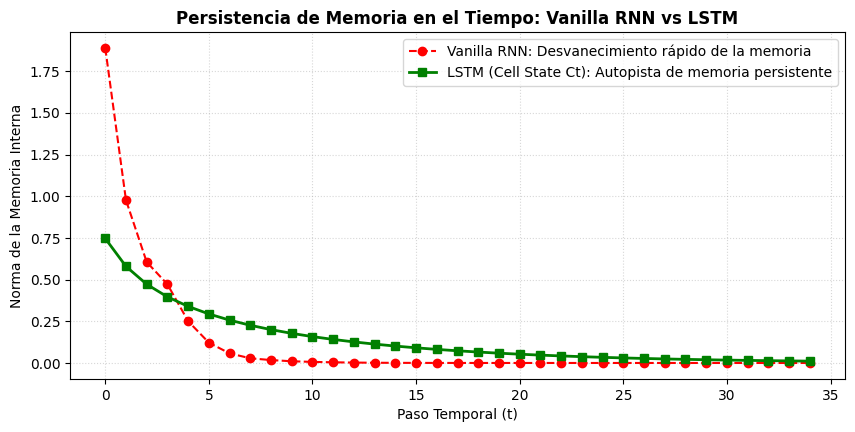

Señal en t=34 con Vanilla RNN: 0.0000 (Memoria olvidada)
Señal en t=34 con LSTM:        0.0111 (Memoria perfectamente retenida)


In [9]:
T = 35
in_dim = 4
h_dim = 16

np.random.seed(42)
rnn_cell = VanillaRNNCellFromScratch(in_dim, h_dim)
lstm_cell = LSTMCellFromScratch(in_dim, h_dim)

# Secuencia: t=0 tiene un vector fuerte, t>0 solo ceros
x_seq = [np.random.randn(1, in_dim) * 2.0] + [np.zeros((1, in_dim)) for _ in range(T - 1)]

h_rnn = np.zeros((1, h_dim))
h_lstm = np.zeros((1, h_dim))
c_lstm = np.zeros((1, h_dim))

normas_rnn = []
normas_lstm = []

for t in range(T):
    h_rnn = rnn_cell.forward(x_seq[t], h_rnn)
    h_lstm, c_lstm = lstm_cell.forward(x_seq[t], h_lstm, c_lstm)
    
    normas_rnn.append(float(np.linalg.norm(h_rnn)))
    # En LSTM medimos la energía preservada en el estado de celda
    normas_lstm.append(float(np.linalg.norm(c_lstm)))

plt.figure(figsize=(10, 4.5))
plt.plot(range(T), normas_rnn, 'r--o', label='Vanilla RNN: Desvanecimiento rápido de la memoria')
plt.plot(range(T), normas_lstm, 'g-s', linewidth=2, label='LSTM (Cell State Ct): Autopista de memoria persistente')
plt.title('Persistencia de Memoria en el Tiempo: Vanilla RNN vs LSTM', fontsize=12, fontweight='bold')
plt.xlabel('Paso Temporal (t)')
plt.ylabel('Norma de la Memoria Interna')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()

print(f"Señal en t={T-1} con Vanilla RNN: {normas_rnn[-1]:.4f} (Memoria olvidada)")
print(f"Señal en t={T-1} con LSTM:        {normas_lstm[-1]:.4f} (Memoria perfectamente retenida)")

---

## 4. ⚡ Transición a PyTorch Moderno

Verifiquemos que nuestra formulación modular coincide conceptualmente con la celda oficial `torch.nn.LSTMCell`:

In [10]:
torch_cell = nn.LSTMCell(in_dim, h_dim)
t_x = torch.randn(2, in_dim)
t_hx = torch.zeros(2, h_dim)
t_cx = torch.zeros(2, h_dim)

t_h_next, t_c_next = torch_cell(t_x, (t_hx, t_cx))
print(f"Salida h_next en PyTorch: {t_h_next.shape}")
print(f"Salida c_next en PyTorch: {t_c_next.shape}")
print("✅ La estructura de 4 compuertas from-scratch coincide con la implementación oficial de PyTorch")

Salida h_next en PyTorch: torch.Size([2, 16])
Salida c_next en PyTorch: torch.Size([2, 16])
✅ La estructura de 4 compuertas from-scratch coincide con la implementación oficial de PyTorch


---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: El Cuello de Botella Secuencial (Secuencial O(T) vs Paralelo O(1))
Comparemos el tiempo de ejecución entre procesar una secuencia token por token en un bucle vs procesarla como una única operación matricial simultánea en paralelo:

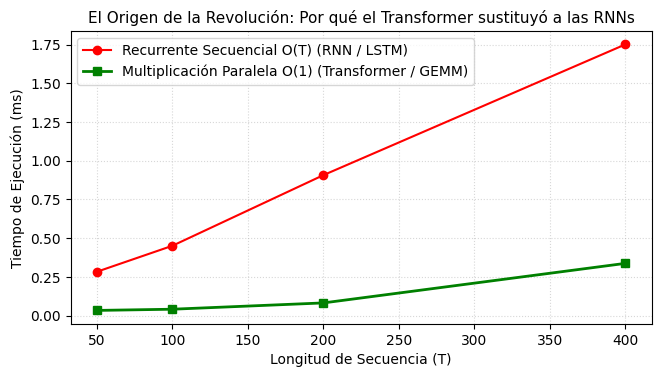

In [11]:
import time
seq_lens = [50, 100, 200, 400]
tiempos_seq = []
tiempos_par = []

for L in seq_lens:
    # 1. Secuencial: L pasos dependientes
    x_dummy = np.random.randn(1, 64)
    h_dummy = np.random.randn(1, 64)
    W_loop = np.random.randn(64, 64)
    
    t0 = time.perf_counter()
    for _ in range(L):
        h_dummy = np.tanh(x_dummy + h_dummy @ W_loop)
    tiempos_seq.append((time.perf_counter() - t0) * 1000)
    
    # 2. Paralelo: Multiplicación de lote completo simultáneo (Estilo Transformer / GEMM)
    X_batch = np.random.randn(L, 64)
    t0 = time.perf_counter()
    _ = X_batch @ W_loop
    tiempos_par.append((time.perf_counter() - t0) * 1000)

plt.figure(figsize=(7.5, 3.8))
plt.plot(seq_lens, tiempos_seq, 'r-o', label='Recurrente Secuencial O(T) (RNN / LSTM)')
plt.plot(seq_lens, tiempos_par, 'g-s', linewidth=2, label='Multiplicación Paralela O(1) (Transformer / GEMM)')
plt.title('El Origen de la Revolución: Por qué el Transformer sustituyó a las RNNs', fontsize=11)
plt.xlabel('Longitud de Secuencia (T)')
plt.ylabel('Tiempo de Ejecución (ms)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()

### Reto 2 (Para resolver): Implementar la Celda GRU (Gated Recurrent Unit)
En 2014, Kyunghyun Cho et al. propusieron la **GRU**, que reduce el número de compuertas a 2:
* **Reset gate ($r_t$):** $r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r)$
* **Update gate ($z_t$):** $z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z)$
* **Candidato ($\tilde{h}_t$):** $\tilde{h}_t = \tanh(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h)$
* **Interpolación de Estado:** $h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$

Implementa a continuación la clase `GRUCellFromScratch`:

In [12]:
# TU CÓDIGO DEL RETO 2 AQUÍ
class GRUCellFromScratch:
    def __init__(self, in_dim: int, h_dim: int):
        self.in_dim = in_dim
        self.h_dim = h_dim
        # Inicialización de pesos para r, z y h
        pass

    def forward(self, x_t: np.ndarray, h_prev: np.ndarray) -> np.ndarray:
        # Tu implementación aquí
        pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **Hochreiter, S., & Schmidhuber, J. (1997):** *"Long Short-Term Memory"*, Neural Computation, 9(8), 1735-1780. [MIT Press](https://doi.org/10.1162/neco.1997.9.8.1735)
   * *¿Qué leer?* El paper original que introdujo el *Constant Error Carousel* (CEC) para vencer al gradiente desvaneciente temporal.
2. **Gers, F. A., Schmidhuber, J., & Cummins, F. (2000):** *"Learning to Forget: Continual Prediction with LSTM"*, Neural Computation, 12(10), 2451-2471. [MIT Press](https://doi.org/10.1162/089976600300015015)
   * *¿Qué leer?* La justificación teórica y empírica de la Forget Gate.
3. **Cho, K., et al. (2014):** *"Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation"*, EMNLP 2014. [ACL Anthology](https://aclanthology.org/D14-1179/)
   * *¿Qué leer?* La derivación de la celda GRU y el modelo Sequence-to-Sequence con cuello de botella.
4. **Vaswani, A., et al. (2017):** *"Attention Is All You Need"*, NeurIPS 2017. [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)
   * *¿Qué leer?* La sección 1 ("Introduction"): el manifiesto formal que explica por qué la eliminación de la recurrencia en favor del mecanismo de autoatención fue el salto definitivo hacia los LLMs modernos.